In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("netflix_titles.csv")
df.head(10)
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [20]:
# understand datasets of netflix
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [21]:
# check missing value exist or not
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [22]:
#checking duplicates
df.duplicated().sum()


np.int64(0)

In [23]:
# fill missing value to unknown
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [24]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [25]:
# handle date section
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [26]:
# doing basic analysis Total movies And Tv shows
df["type"].value_counts()
# percenatge
# df["type"].value_counts(normalize=True) * 100
# # top 10 contries
# df["country"].value_counts().head(10)
# # top 10 ratings
# df["country"].value_counts().head(10)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

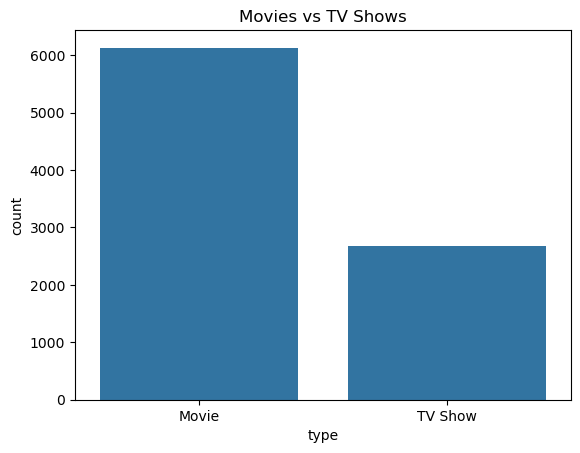

In [27]:
# basic analysis visualization
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.show()

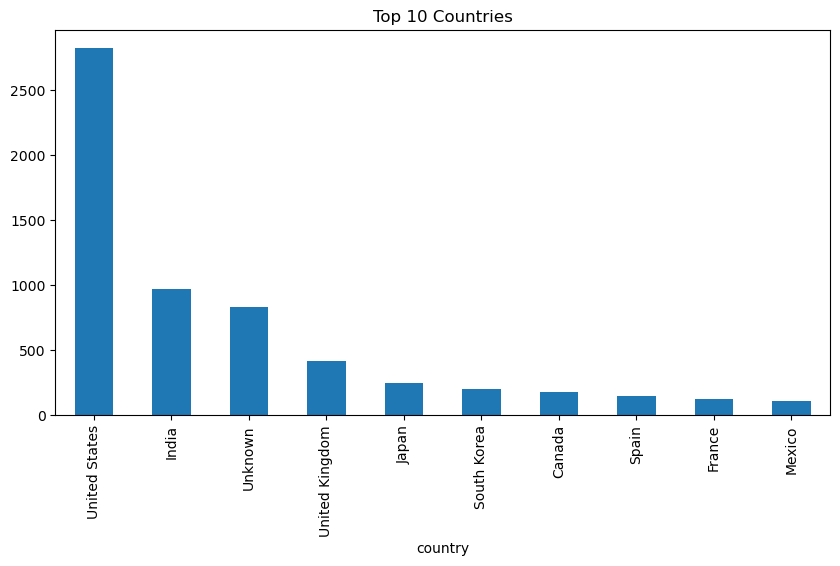

In [28]:
# 2nd Top countries
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_country.plot(kind="bar")
plt.title("Top 10 Countries")
plt.show()

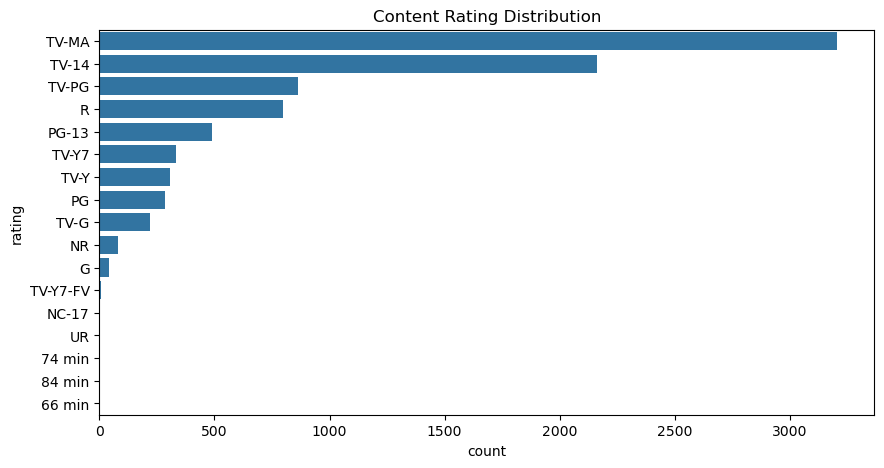

In [15]:
# "Content Rating Distribution"
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)

plt.title("Content Rating Distribution")
plt.show()

In [ ]:
df.to_csv(
    "cleaned_netflix.csv",
    index=False
)

In [17]:
print(df.columns.tolist())

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added']


In [18]:
df["year_added"].head()

0    2021.0
1    2021.0
2    2021.0
3    2021.0
4    2021.0
Name: year_added, dtype: float64

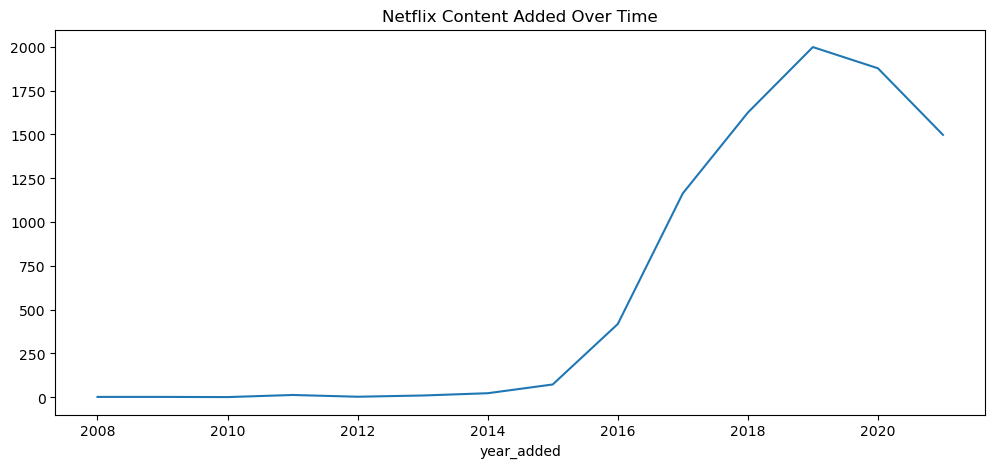

In [20]:
plt.figure(figsize=(12,5))

df["year_added"].value_counts()\
.sort_index().plot()

plt.title("Netflix Content Added Over Time")
plt.show()

In [21]:
# Content added each year
content_growth = (
    df.groupby('year_added')
      .size()
      .reset_index(name='content_count')
)

content_growth

,year_added,content_count
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,10
6,2014.0,23
7,2015.0,73
8,2016.0,418
9,2017.0,1164


In [22]:
# PEAK GROWTH YEAR
peak_year = content_growth.loc[
    content_growth['content_count'].idxmax()
]

print("Peak Year:")
print(peak_year)

Peak Year:
year_added       2019.0
content_count    1999.0
Name: 11, dtype: float64


In [23]:
#How has Netflix's content library grown over time?
# The objective is to understand how Netflix expanded its content catalog over the years and identify periods of rapid growth.
content_growth = (
    df.groupby('year_added')
      .size()
      .reset_index(name='content_count')
)

content_growth

,year_added,content_count
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,10
6,2014.0,23
7,2015.0,73
8,2016.0,418
9,2017.0,1164


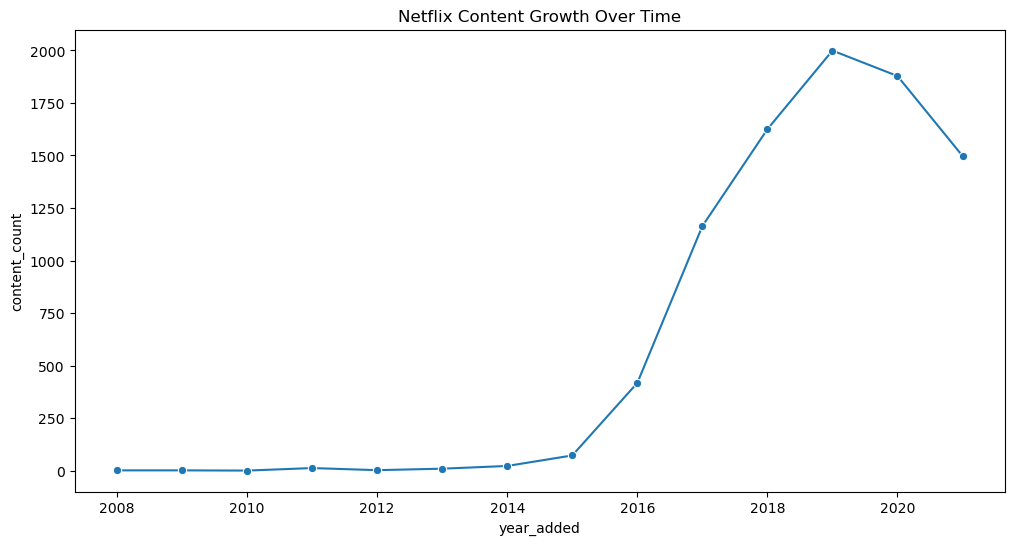

In [24]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=content_growth,
    x='year_added',
    y='content_count',
    marker='o'
)

plt.title("Netflix Content Growth Over Time")
plt.show()

# Is Netflix Becoming More International?

## Business Question
Did Netflix rely only on the United States, or did it expand globally by increasing content from other countries over time?

We will analyze how content production changed across major countries from 2008 to 2021.

In [25]:
countries = (
    df['country']
    .str.split(', ')
    .explode()
)

countries.head()

0    United States
1     South Africa
2              NaN
3              NaN
4            India
Name: country, dtype: object

In [26]:
top5 = countries.value_counts().head(5)

top5  #TOP 5 COUNTRIES

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64

In [27]:
country_year = (
    df.assign(
        country=df['country']
        .str.split(', ')
    )
    .explode('country')
)

In [28]:
country_year.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [29]:
# Count Content by Country and Year
country_growth = (
    country_year
    .groupby(['year_added','country'])
    .size()
    .reset_index(name='content_count')
)

country_growth.head()

,year_added,country,content_count
0,2008.0,United States,2
1,2009.0,Denmark,1
2,2009.0,United States,1
3,2010.0,United States,1
4,2011.0,France,2


In [30]:
top5_list = top5.index

filtered = country_growth[
    country_growth['country'].isin(top5_list)
]

filtered.head()

,year_added,country,content_count
0,2008.0,United States,2
2,2009.0,United States,1
3,2010.0,United States,1
4,2011.0,France,2
7,2011.0,United Kingdom,1


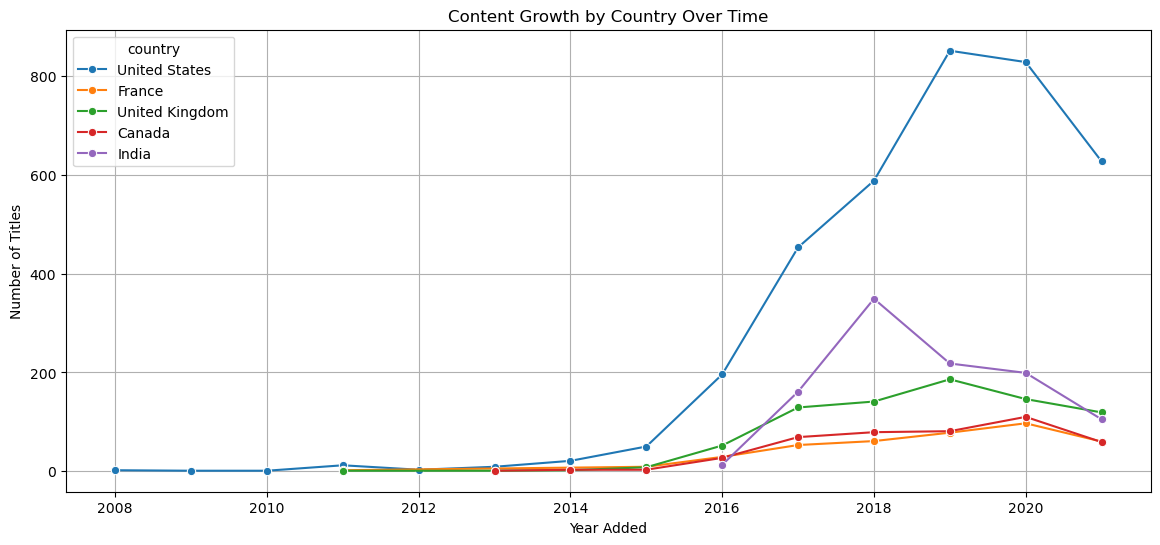

In [31]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=filtered,
    x='year_added',
    y='content_count',
    hue='country',
    marker='o'
)

plt.title('Content Growth by Country Over Time')

plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

# OBSERVATION
• United States consistently contributes the highest amount of content.

• India shows significant growth after 2016.

• United Kingdom, Canada, and Japan also increase their contributions over time.

• Multiple countries experience growth simultaneously between 2016 and 2020.

• The gap between the United States and other countries narrows slightly after 2016.

# Q Which Genres Dominate Netflix?



In [35]:
# Split genres
genre_df = (
    df.assign(
        genre=df['listed_in'].str.split(', ')
    )
    .explode('genre')
)

# Split countries
genre_df = (
    genre_df.assign(
        country=genre_df['country'].str.split(', ')
    )
    .explode('country')
)

# Top countries
top_countries = (
    genre_df['country']
    .value_counts()
    .head(10)
    .index
)

# Top genres
top_genres = (
    genre_df['genre']
    .value_counts()
    .head(10)
    .index
)

# Filter data
filtered = genre_df[
    (genre_df['country'].isin(top_countries))
    &
    (genre_df['genre'].isin(top_genres))
]

# Create pivot table
pivot = pd.crosstab(
    filtered['country'],
    filtered['genre']
)

pivot

genre,Action & Adventure,Children & Family Movies,Comedies,Documentaries,Dramas,Independent Movies,International Movies,International TV Shows,TV Dramas,Thrillers
country,,,,,,,,,,
Canada,44,80,94,42,82,44,60,25,32,49
France,37,23,51,44,167,73,207,43,27,44
Germany,33,17,42,21,80,31,94,35,19,28
India,137,26,323,27,662,167,864,66,28,92
Japan,57,19,9,7,23,7,72,151,21,5
Mexico,9,5,24,18,44,23,70,43,12,2
South Korea,17,10,17,2,26,2,44,152,38,14
Spain,10,9,47,21,76,20,140,54,11,38
United Kingdom,84,46,91,127,196,74,168,128,36,61


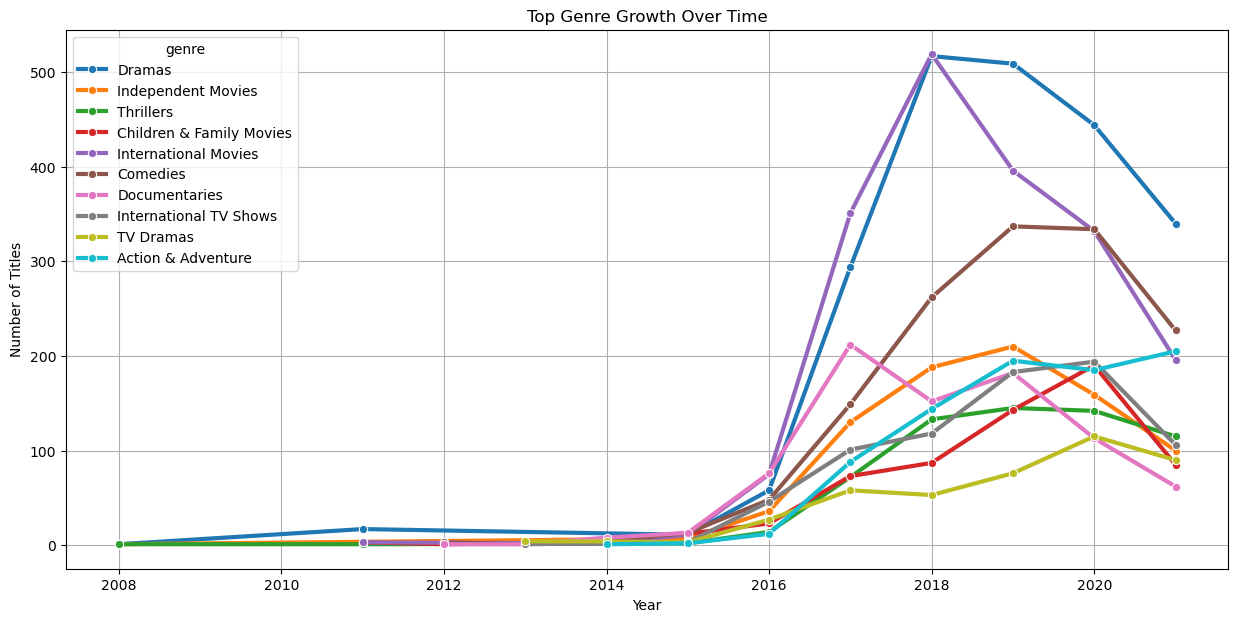

In [43]:
# Top Genre Growth Over Time 
plt.figure(figsize=(15,7))

sns.lineplot(
    data=genre_growth,
    x='year_added',
    y='count',
    hue='genre',
    marker='o',
    linewidth=3
)

plt.title(
    'Top Genre Growth Over Time'
)

plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()
# genre_growth = (
#     filtered.groupby(['year_added','genre'])
#     .size()
#     .reset_index(name='count')
# )

In [44]:
# Split countries
country_df = (
    df.assign(
        country=df['country'].str.split(', ')
    )
    .explode('country')
)

# Top 5 countries
top5 = (
    country_df['country']
    .value_counts()
    .head(5)
    .index
)

# Content count by year and country
country_growth = (
    country_df.groupby(
        ['year_added', 'country']
    )
    .size()
    .reset_index(name='content_count')
)

# Filter top 5 countries
filtered = country_growth[
    country_growth['country'].isin(top5)
]

filtered.head()

,year_added,country,content_count
0,2008.0,United States,2
2,2009.0,United States,1
3,2010.0,United States,1
4,2011.0,France,2
7,2011.0,United Kingdom,1


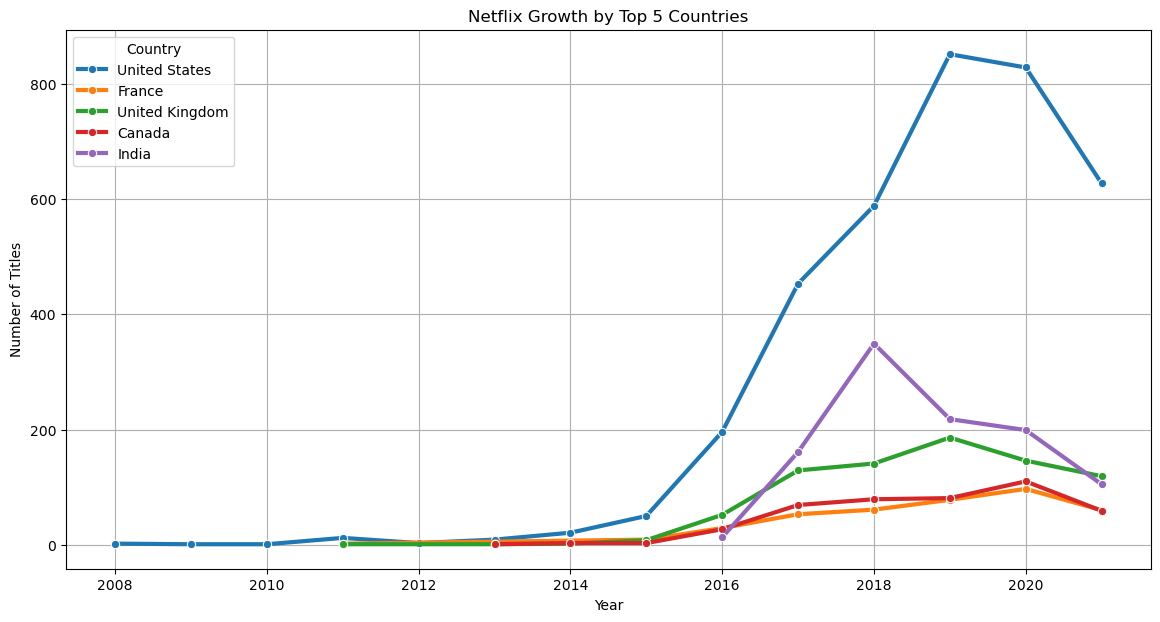

In [45]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=filtered,
    x='year_added',
    y='content_count',
    hue='country',
    marker='o',
    linewidth=3
)

plt.title(
    'Netflix Growth by Top 5 Countries'
)

plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.legend(title='Country')

plt.show()

In [46]:
top_directors = (
    df['director']
    .value_counts()
    .head(15)
)

top_directors

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Yılmaz Erdoğan             8
Lance Bangs                8
Kunle Afolayan             8
Name: count, dtype: int64

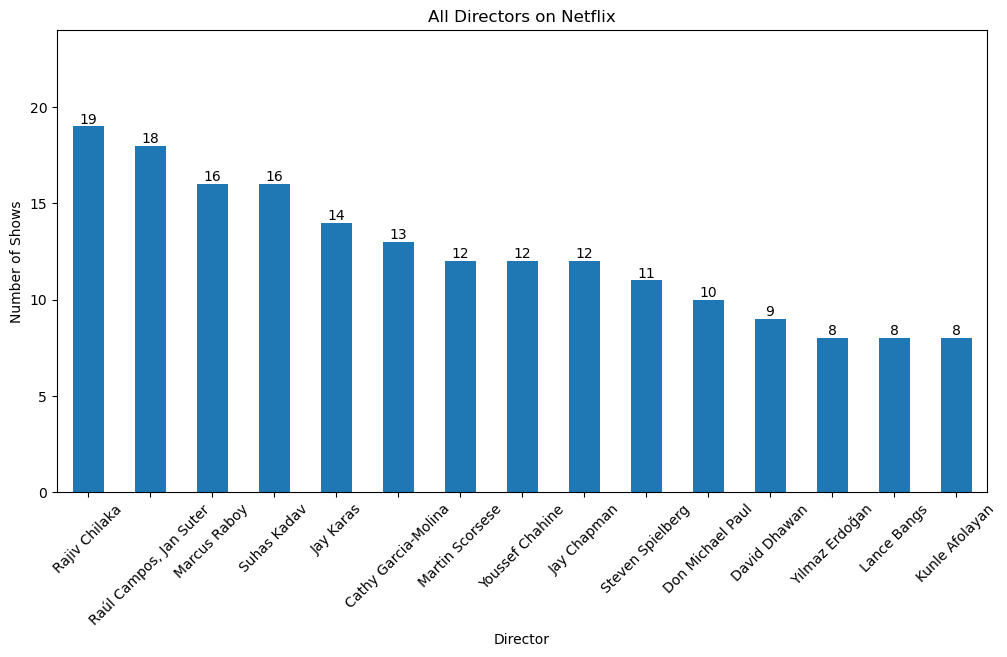

In [47]:
ax = top_directors.plot(
    kind='bar',
    figsize=(12,6)
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("All Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Shows")

plt.ylim(0, top_directors.max() + 5)

plt.xticks(rotation=45)

plt.show()

In [48]:
top_directors = df['director'].value_counts().head(5)

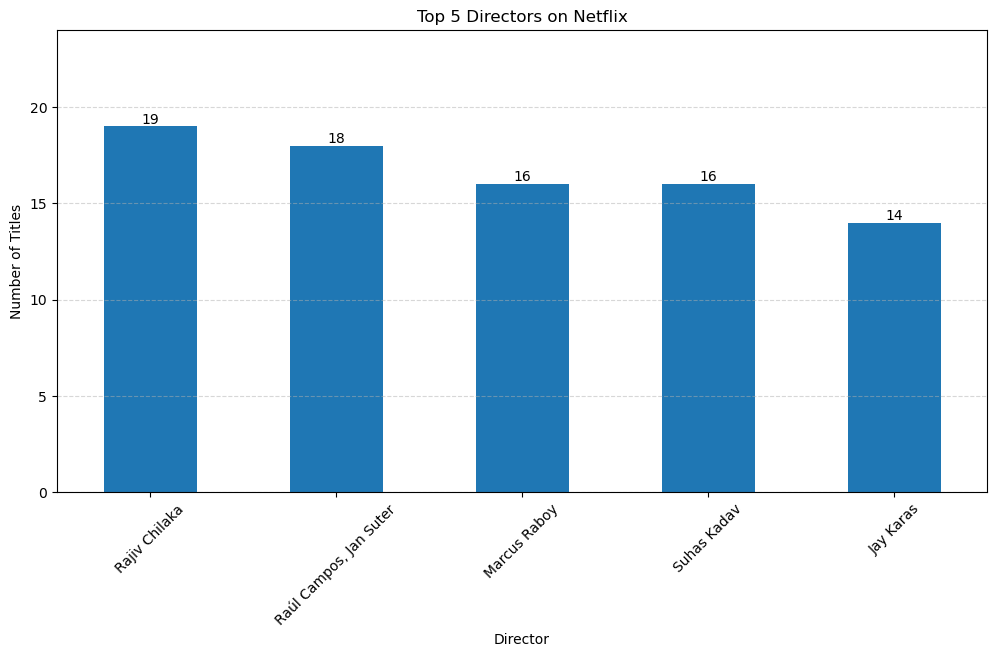

In [49]:
top_directors = df['director'].value_counts().head(5)

ax = top_directors.plot(
    kind='bar',
    figsize=(12,6)
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Top 5 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.ylim(0, top_directors.max() + 5)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()